# 4: Play around

Step 3.6 learned us that 
- Full model works the best, implement that here and let it predict.
- Using angle specific models does not help, so we don't use them here. 
Earlier phase learned that cropping helps! So we do taht here too. 

## 4.1 system setup

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
import os
import matplotlib.image as mpimg
import matplotlib.pyplot as plt
import pandas as pd
sys.path.append('../../utils')
import requests
import numpy as np
from ultralytics import YOLO
from  configloader import Configloader
import cnn_helpers
import implot
import file_io
import style
import car_detection as cd
import platform_dependency as plf

In [3]:
cnn_helpers.system_override()
device = cnn_helpers.system_pick_device()

System override applied - check if GPU is detected
Using GPU for deep learning.


In [4]:
config = Configloader()
yolo_path = os.path.join(config.get('directories','root_dir'), config.get('directories', 'yolo_path'))

In [5]:
CNN_SHAPE = 224
MODELDIR = os.path.join(
    config.get('directories', 'root_dir'), 
    config.get('directories', 'final_models_dirname'), 
    config.get('directories', 'brandphase'),
    )

CROP = True  #crop on bbox

In [6]:
detected_os = plf.get_platform()
if detected_os == 'Linux':
    print('A unix system was detected, please follow these steps to patch a known UNIX bug:')
    print('https://askubuntu.com/questions/1299255/how-can-i-solve-no-module-named-lzma')
    
detected_gpu = plf.get_gpu_info()
if detected_gpu == False:
    print(f'Notebook detected {detected_os} as OS and will use CPU for tasks where it can be done')
else:
    print(f'Notebook detected {detected_os} as OS and will use the available {detected_gpu} GPU')
    if detected_gpu != 'amd': 
        print(f"{detected_gpu} GPU's were not tested - code required workarounds to get working on AMD - no guarantees given.")


yolomodel = YOLO(yolo_path)  # YOLOv8 nano for speed, or 'yolov8s.pt' for more accuracy
if detected_gpu == 'amd': 
    yolomodel = plf.yolo_override(yolomodel)        

A unix system was detected, please follow these steps to patch a known UNIX bug:
https://askubuntu.com/questions/1299255/how-can-i-solve-no-module-named-lzma
Notebook detected Linux as OS and will use the available amd GPU
CPU override applied to model


In [ ]:
from tensorflow.keras import backend as K
import gc
import uuid

dfr = None
def predict_something(image_urls): 
    tempdir = 'temp'
    os.makedirs(tempdir, exist_ok=True)
    yolomodel = YOLO(yolo_path)  # YOLOv8 nano for speed, or 'yolov8s.pt' for more accuracy
    if detected_gpu == 'amd': 
        yolomodel = plf.yolo_override(yolomodel)
    for image_url in image_urls: 
        assert image_url.endswith('.jpg')
        uuid_v4 = str(uuid.uuid4())

        save_path = os.path.join(tempdir, f"{uuid_v4}.jpg")
        spoof_headers = {
            "User-Agent": "Mozilla/5.0"
        }

        # Download and save
        response = requests.get(image_url, headers=spoof_headers)
        if response.status_code == 200:
            with open(save_path, "wb") as f:
                f.write(response.content)
        else:
            print(f"Download failed: {response.status_code}")
    data = []
    for file in os.listdir(tempdir):
        path = os.path.abspath(os.path.join(tempdir, file))
        details = cd.is_full_car(path, yolomodel)
        if details[0]: 
            xtop = int(details[2][0])
            ytop = int(details[2][1])
            xlow = int(details[2][2])
            ylow = int(details[2][3])
        else:
            xtop = -1
            ytop = -1
            xlow = -1
            ylow = -1
        data.append([path, xtop, ytop, xlow, ylow, 'fake_entry'])
        
    df = pd.DataFrame(data, columns= ['abs_path', 'yolobox_top_left_x', 'yolobox_top_left_y', 'yolobox_bottom_right_x', 'yolobox_bottom_right_y', 'brand'])

    basedir = config.get('directories', 'root_dir')
    fm = config.get('directories', 'final_models_dirname')
    phase = 'brand'
    best_approach = 'CNN_based_models'
    full = 'full'
    full_dir = os.path.join(basedir, fm, phase, best_approach,full)
    p,a,decode = cnn_helpers.infer_cnn(full_dir, df, CROP, CNN_SHAPE)
    for row, dfr in zip(p, df.iterrows()): 
        i = np.argmax(row)
        img = mpimg.imread(dfr[1]['abs_path'])
        plt.imshow(img)
        plt.title(f"{decode[i]} ({row[i]})")
        K.clear_session()
        gc.collect()
        plt.show()
    cnn_helpers.wipe_slate(tempdir)

CPU override applied to model


,abs_path,yolobox_top_left_x,yolobox_top_left_y,yolobox_bottom_right_x,yolobox_bottom_right_y,brand
0,/home/frederic/Documents/automotive_project/no...,-1,-1,-1,-1,fake_entry
1,/home/frederic/Documents/automotive_project/no...,57,106,641,368,fake_entry
2,/home/frederic/Documents/automotive_project/no...,-1,-1,-1,-1,fake_entry
3,/home/frederic/Documents/automotive_project/no...,1558,225,2559,1213,fake_entry
4,/home/frederic/Documents/automotive_project/no...,70,129,550,515,fake_entry


[array([ 0.00040375,  8.9604e-06,    0.032452,     0.23925,   0.0042144,  7.0906e-05,   0.0015077,    0.009552,   0.0016271,  0.00021496,   0.0001331,   0.0016013,   0.0038169,    0.025855,   0.0023255,   0.0010447,    0.042637,    0.034768,   0.0065498,   0.0020258,  0.00085321,     0.56016,   0.0023693,  0.00018202,
        0.00020654,   0.0011678,  0.00070335,    0.018185,   0.0042033,   0.0019115], dtype=float32), array([  1.159e-17,  2.1441e-19,  2.6227e-16,  4.9389e-13,  1.6584e-14,  5.2952e-14,   1.082e-18,  1.8213e-14,  4.6242e-13,           1,  1.9083e-20,  7.0065e-12,  1.5707e-15,  4.1425e-15,   2.818e-17,  2.3637e-08,   1.394e-14,  1.3772e-14,  3.3173e-14,  1.0713e-11,  1.0996e-13,   9.286e-18,  3.6855e-16,  1.0595e-16,
        2.7271e-17,  4.5807e-12,  3.0705e-14,  3.3291e-12,  3.3391e-14,  5.5433e-15], dtype=float32), array([ 0.00013587,  1.4776e-10,   0.0014942,     0.48192,    0.019435,   0.0013113,   0.0039351,    0.056299,  2.9904e-05,  4.5064e-05,   0.0087798,  0.0002

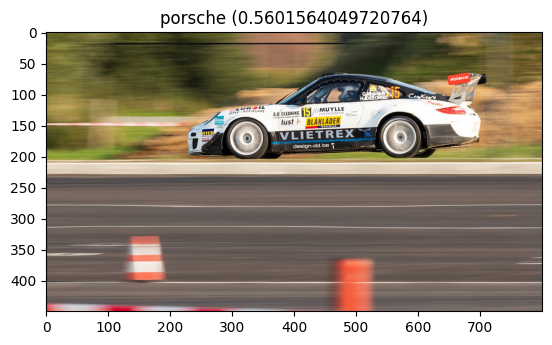

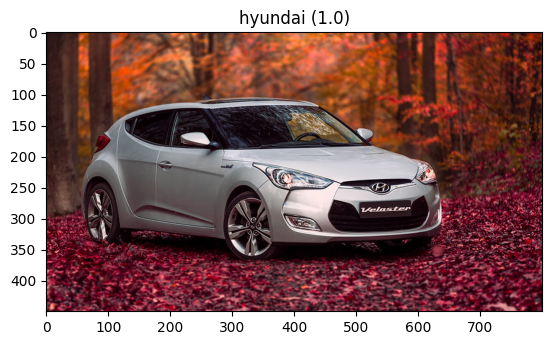

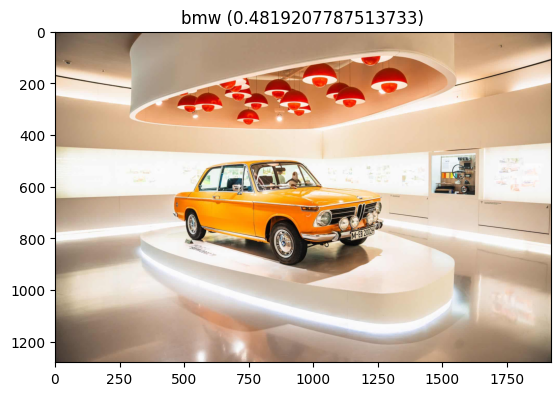

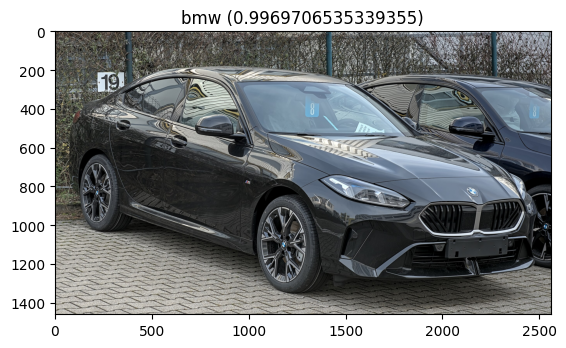

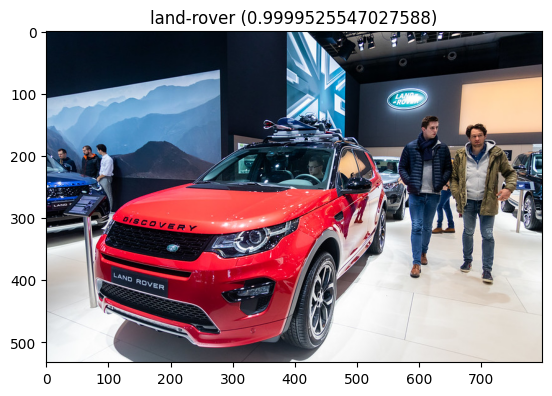

In [17]:
demo = [
    'https://live.staticflickr.com/7911/47234247942_87389399b9_c.jpg', 
    'https://live.staticflickr.com/1846/43543992205_8684355315_c.jpg', 
    'https://live.staticflickr.com/655335/50600295136_fb98b93983_c.jpg', 
    'https://upload.wikimedia.org/wikipedia/commons/thumb/f/ff/BMW_220d_%28F74%29_DSC_7359.jpg/2560px-BMW_220d_%28F74%29_DSC_7359.jpg',
    'https://cdn.bmwblog.com/wp-content/uploads/2024/08/bmw-museum-munich56.jpg'
    ]

predict_something(demo)